### <font color="blue"> Housing Data -  Correlation Analysis </font> ###

### <font color="blue"> Ingesting Housing Data </font> ###

In [17]:
import pandas as pd

# Reading Housing data Excel file into a Data Frame
housing_data = pd.read_excel('Housing Data_Project_Task 1.XLS', engine='xlrd', sheet_name=1)

# Housing dataset info
print("Shape of Housing dataset: ")
print("(No.of Rows, No.of Columns): ", housing_data.shape)
print("\n")

print("First five rows of data set, for quick verification: \n")
housing_data.head()

Shape of Housing dataset: 
(No.of Rows, No.of Columns):  (108, 7)


First five rows of data set, for quick verification: 



,ID,Price,SQFT,BEDS,BATHS,CARS,AGE
0,H1,100000,912,3,1,1,31
1,H2,599000,1238,2,1,-1,12
2,H3,615000,816,2,1,1,19
3,H4,635000,1008,4,1,1,17
4,H5,640000,1707,2,1,1,13


### <font color="blue"> Descriptive Statistics </font> ###

In [18]:
# Descriptive statistics 
housing_data.describe()

,Price,SQFT,BEDS,BATHS,CARS,AGE
count,1.080000e+02,108.000000,108.000000,108.000000,108.000000,108.000000
mean,9.785556e+05,1860.435185,2.611111,1.666667,1.064815,11.342593
std,2.837289e+05,736.575078,0.829743,0.595936,0.498093,4.975007
min,1.000000e+05,816.000000,0.000000,1.000000,-1.000000,1.000000
25%,7.930000e+05,1417.500000,2.000000,1.000000,1.000000,8.000000
50%,9.245000e+05,1793.000000,2.500000,2.000000,1.000000,11.000000
75%,1.122250e+06,2112.000000,3.000000,2.000000,1.000000,14.000000
max,1.950000e+06,6000.000000,7.000000,4.000000,4.000000,31.000000


### <font color="blue"> Descriptive Statistics - Mean & Standard Deviation </font> ###

In [19]:
# Descriptive Statistics: Mean & Standard Deviation
housing_data_mean_std = housing_data.describe().loc[['mean', 'std']]
print(housing_data_mean_std)

              Price         SQFT      BEDS     BATHS      CARS        AGE
mean  978555.555556  1860.435185  2.611111  1.666667  1.064815  11.342593
std   283728.919373   736.575078  0.829743  0.595936  0.498093   4.975007


### <font color="blue"> Corelation Analysis - Before removing Outliers </font> ###

Correlation of Price with Other Variables (Before removing Outliers):


,SQFT,BEDS,BATHS,CARS,AGE
Price,0.372328,0.2357,0.54665,0.541154,-0.445672


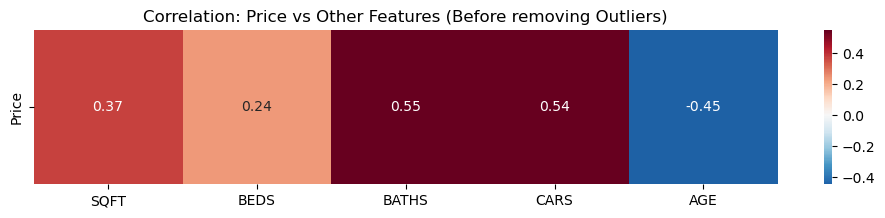

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns and exclude 'House Id'
numeric_df = housing_data.select_dtypes(include=['number']).drop(columns=['ID'], errors='ignore')

# Calculate the correlation matrix
corr_matrix = numeric_df.corr()

# Remove 'price' vs 'price', as it is always 1.0 and keeping 'Price' as horizontal row
price_vs_others = corr_matrix.loc[['Price']].drop(columns=['Price'])

# Display the correlation
print("Correlation of Price with Other Variables (Before removing Outliers):")
display(price_vs_others)

# Heatmap for correlation vusualization
plt.figure(figsize=(12, 2))
sns.heatmap(price_vs_others, annot=True, cmap='RdBu_r', center=0)
plt.title("Correlation: Price vs Other Features (Before removing Outliers)")
plt.show()

### <font color="blue"> Corelation Interpretation (Before removing Outliers) </font> ###

### <font color="Green"> Positive Correlation: </font> ###
Price of the house is in positive correlation with Square Feet, Numbers of Beds, Number of Baths, Number of Parking Spaces. 
They move in the same direction. If any of these parameters- Area in Square Feet, Numbers of Beds, Number of Baths, Number of Parking Spaces increases, 
the Price of the house will also increase.
### <font color="Green"> Moderate Positive Correlation: </font> ###
Number of Baths and Number of Parking Spaces are in moderate positive correlation with Price of the house, as the correlation value is > 0.5 and <0. 7.
### <font color="Green"> Weak Positive Correlation: </font> ###    
Area in Square Feet and Numbers of Beds are in weak positive correlation with Price of the house, as the correlation value is < 0.4.

### <font color="Red"> Negative Correlation: </font> </font> ###
Price of the house is in negative correlation with the Age of the house. They move in opposite direction. If the Age of the house increases, the Price of the house will decrease. 
### <font color="Red"> Moderate Negative Corelation </font> ###
Age of the house is in Moderate neagtive corelation with the Price of the house, as the corelation value -0.45 is closer to 0.5.

    

### <font color="blue"> Handling Outliers for each variable using Z-Score</font> ###

In [21]:
import numpy as np
from scipy import stats

# Consider numeric columns
target_columns = [
    'Price', 'SQFT', 'BEDS', 
    'BATHS', 'CARS', 'AGE'
]

# Create a copy to keep your original data safe
housing_data_cleaned = housing_data.copy()

print(f"Outlier Details (Total Rows: {len(housing_data)}) \n")

# Iterate through each column one by one
for col in target_columns:
    # Calculate Z-score for the current column
    # Formula: z = (x - mean) / std
    z_scores = stats.zscore(housing_data_cleaned[col])
    abs_z_scores = np.abs(z_scores)
    
    # Identify the outliers (where Z-score > 3 or < -3)
    outlier_mask = abs_z_scores > 3
    outlier_data = housing_data_cleaned[outlier_mask]
    
   # Print the outliers found for this column
    print(f"Checking Column: [{col}]")
    if not outlier_data.empty:
        print(f"FOUND {len(outlier_data)} outliers:")
        # Displaying the House Id and the specific value that triggered the outlier
        print(outlier_data[['ID', col]])
    else:
        print("No outliers found for this column.")
    
    # Remove Outliers from the working DataFrame
    housing_data_cleaned = housing_data_cleaned[~outlier_mask]
    print(f"Rows remaining after removing Outliers in {col}: {len(housing_data_cleaned)}")
    print("-" * 50)

print(f"\nFinal cleaned dataset size: {len(housing_data_cleaned)}")

Outlier Details (Total Rows: 108) 

Checking Column: [Price]
FOUND 4 outliers:
       ID    Price
0      H1   100000
105  H106  1910000
106  H107  1920000
107  H108  1950000
Rows remaining after removing Outliers in Price: 104
--------------------------------------------------
Checking Column: [SQFT]
FOUND 3 outliers:
     ID  SQFT
8    H9  6000
22  H23  5000
38  H39  5000
Rows remaining after removing Outliers in SQFT: 101
--------------------------------------------------
Checking Column: [BEDS]
FOUND 2 outliers:
     ID  BEDS
79  H80     0
95  H96     7
Rows remaining after removing Outliers in BEDS: 99
--------------------------------------------------
Checking Column: [BATHS]
FOUND 1 outliers:
      ID  BATHS
99  H100      4
Rows remaining after removing Outliers in BATHS: 98
--------------------------------------------------
Checking Column: [CARS]
FOUND 2 outliers:
     ID  CARS
1    H2    -1
98  H99     3
Rows remaining after removing Outliers in CARS: 96
----------------------

### <font color="blue"> Corelation Analysis - After removing Outliers <font> ###

Correlation of Price with Other Variables (After removing Outliers):


,SQFT,BEDS,BATHS,CARS,AGE
Price,0.774087,0.221731,0.573883,0.435887,-0.2847


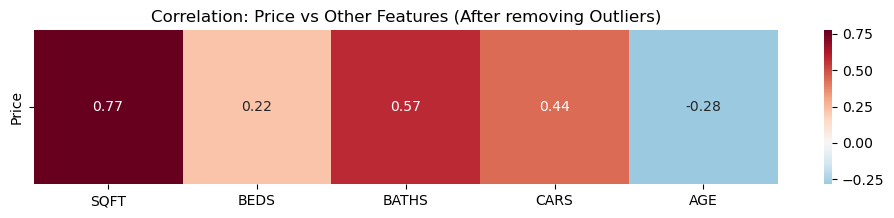

In [24]:
# Select only numeric columns and exclude 'House Id'
numeric_df = housing_data_cleaned.select_dtypes(include=['number']).drop(columns=['ID'], errors='ignore')

# Calculate the correlation matrix
corr_matrix = numeric_df.corr()

# Remove 'price' vs 'price', as it is always 1.0 and keeping 'Price' as horizontal row
price_vs_others = corr_matrix.loc[['Price']].drop(columns=['Price'])

# Display correlation
print("Correlation of Price with Other Variables (After removing Outliers):")
display(price_vs_others)

# Heatmap for visualization
plt.figure(figsize=(12, 2))
sns.heatmap(price_vs_others, annot=True, cmap='RdBu_r', center=0)
plt.title("Correlation: Price vs Other Features (After removing Outliers)")
plt.show()

### <font color="blue"> Corelation Interpretation (After removing Outliers) </font> ###

### In summary the correlation values got changed after removing the outliers. ###

- Price is in Strong positive correlation with the Area in Square Feet, as its correlation value is > 0.7, which reflects the realistic housing market scenarios. 
It means, if the Square Feet of the house increases, definitely the Price of the house will increase. Before handling outliers, Price was in weak positive corelation with the Area of the house. The corelation value got changed from 0.37 to 0.77

- Price is in weak positive corelation with the Number of Beds, as its correltion value is < 0.4, which is almost the same case before removing outliers too.

- Price is in moderate positive correlation with the Number of Baths, as its correltion value is > 0.5, which is almost the same case before removing outliers too. 

- Price is in moderate positive correlation with the Number of Parking space, as its correltion value is closer to 0.5. But after handling outliers the correlation value got changed from 0.54 to 0.44.

- Price is in weak negative correlation with the Age of the house, as its correltion value is < 0.3. After handling outliers, the correlation value got changed from -0.45 to -0.28.   
    
   
